In [1]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("CUDA build:", tf.test.is_built_with_cuda())
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.10.1
CUDA build: True
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from tqdm.notebook import tqdm

from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.layers import (
    Input,
    Dense,
    Embedding,
    LSTM,
    Dropout,
    Add
)

from tensorflow.keras.models import Model

In [8]:
IMAGE_DIR = "data/Flickr8k_Dataset"
CAPTION_FILE = "data/Flickr8k_text/Flickr8k.token.txt"

TRAIN_FILE = "data/Flickr8k_text/Flickr_8k.trainImages.txt"
VAL_FILE = "data/Flickr8k_text/Flickr_8k.devImages.txt"
TEST_FILE = "data/Flickr8k_text/Flickr_8k.testImages.txt"

In [9]:
captions = {}

with open(CAPTION_FILE, "r", encoding="utf-8") as file:

    for line in file:

        line = line.strip()

        # Skip empty or invalid lines
        if not line or " " not in line:
            continue

        image_id, caption = line.split(" ", 1)

        image_name = image_id.split("#")[0]

        if image_name not in captions:
            captions[image_name] = []

        captions[image_name].append(caption)

In [10]:
len(captions)

8092

In [11]:
for image_name in list(captions.keys())[:3]:

    print("\nIMAGE:", image_name)

    for caption in captions[image_name]:

        print("-", caption)


IMAGE: 1000268201_693b08cb0e.jpg
- child in a pink dress is climbing up a set of stairs in an entry way .
- girl going into a wooden building .
- little girl climbing into a wooden playhouse .
- little girl climbing the stairs to her playhouse .
- little girl in a pink dress going into a wooden cabin .

IMAGE: 1001773457_577c3a7d70.jpg
- black dog and a spotted dog are fighting
- black dog and a tri-colored dog playing with each other on the road .
- black dog and a white dog with brown spots are staring at each other in the street .
- dogs of different breeds looking at each other on the road .
- dogs on pavement moving toward each other .

IMAGE: 1002674143_1b742ab4b8.jpg
- little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .
- little girl is sitting in front of a large painted rainbow .
- small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it .
- is a girl with pigtails sitting in front of a rainbow pain

In [12]:
def clean_caption(caption):

    caption = caption.lower()

    caption = re.sub(r"[^a-z\s]", "", caption)

    caption = re.sub(r"\s+", " ", caption).strip()

    caption = "<start> " + caption + " <end>"

    return caption

In [13]:
caption = "A little girl is playing with a dog."

print(clean_caption(caption))

<start> a little girl is playing with a dog <end>


In [14]:
cleaned_captions = {}

for image_name in captions:

    cleaned_captions[image_name] = []

    for caption in captions[image_name]:

        cleaned = clean_caption(caption)

        cleaned_captions[image_name].append(cleaned)


print(cleaned_captions[list(cleaned_captions.keys())[0]])

['<start> child in a pink dress is climbing up a set of stairs in an entry way <end>', '<start> girl going into a wooden building <end>', '<start> little girl climbing into a wooden playhouse <end>', '<start> little girl climbing the stairs to her playhouse <end>', '<start> little girl in a pink dress going into a wooden cabin <end>']


In [15]:
def load_image_names(file_path):

    images = []

    with open(file_path, "r") as file:

        for line in file:

            images.append(line.strip())

    return images


train_images = load_image_names(TRAIN_FILE)

val_images = load_image_names(VAL_FILE)

test_images = load_image_names(TEST_FILE)

In [16]:
len(train_images)

6000

In [17]:
train_captions = []

for image_name in train_images:

    for caption in cleaned_captions[image_name]:

        train_captions.append(caption)

In [18]:
len(train_captions)

30000

In [19]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    num_words=None,
    oov_token="<unk>",
    filters=""
)
tokenizer.fit_on_texts(train_captions)
vocab_size = len(tokenizer.word_index) + 1

In [20]:
vocab_size

7522

In [21]:
tokenizer.word_index["<start>"]

2

In [22]:
tokenizer.word_index["<end>"]

3

In [23]:
tokenizer.word_index.get("dog")

10

In [24]:
tokenizer.word_index.get("girl")

19

In [25]:
train_sequences = tokenizer.texts_to_sequences(train_captions)

print(train_sequences[0])

[2, 15, 10, 8, 30, 249, 4, 14, 10, 5, 6, 41, 3]


In [26]:
caption_lengths = []

for sequence in train_sequences:
    caption_lengths.append(len(sequence))

max_length = max(caption_lengths)

print("max length:", max_length)
print("avg cap len:", np.mean(caption_lengths))

max length: 36
avg cap len: 11.783933333333334


In [27]:
print("Original:")
print(train_captions[0])

print("\nSequence:")
print(train_sequences[0])

Original:
<start> black dog is running after a white dog in the snow <end>

Sequence:
[2, 15, 10, 8, 30, 249, 4, 14, 10, 5, 6, 41, 3]


In [28]:
from tensorflow.keras.applications import EfficientNetB0

image_encoder = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

image_encoder.trainable = False

print(image_encoder.output_shape)

(None, 1280)


In [29]:
image_name = train_images[0]

image_path = os.path.join(IMAGE_DIR, image_name)

image = tf.keras.utils.load_img(
    image_path,
    target_size=(224, 224)
)

image_array = tf.keras.utils.img_to_array(image)

image_array = np.expand_dims(image_array, axis=0)

image_array = preprocess_input(image_array)

feature = image_encoder.predict(image_array, verbose=0)

print("Image:", image_name)
print("Feature shape:", feature.shape)

Image: 2513260012_03d33305cf.jpg
Feature shape: (1, 1280)


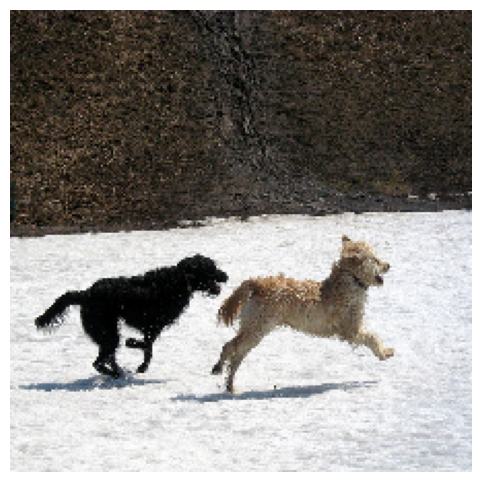

In [30]:
plt.figure(figsize=(6, 6))

plt.imshow(image)

plt.axis("off")

plt.show()

In [29]:
image_features = {}

for image_name in tqdm(train_images):

    image_path = os.path.join(IMAGE_DIR, image_name)

    image = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    image_array = tf.keras.utils.img_to_array(image)

    image_array = np.expand_dims(image_array, axis=0)

    image_array = preprocess_input(image_array)

    feature = image_encoder.predict(
        image_array,
        verbose=0
    )

    image_features[image_name] = feature[0]

print("Images processed:", len(image_features))

  0%|          | 0/6000 [00:00<?, ?it/s]

Images processed: 6000


In [30]:
np.save(
    "train_image_features.npy",
    image_features,
    allow_pickle=True
)

In [3]:
image_features = np.load(
    "train_image_features.npy",
    allow_pickle=True
).item()

print("Images:", len(image_features))

Images: 6000


In [4]:
from tensorflow.keras.utils import Sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

class CaptionDataGenerator(Sequence):

    def __init__(
        self,
        image_features,
        captions,
        image_names,
        tokenizer,
        max_length,
        vocab_size,
        batch_size=64,
        shuffle=True
    ):

        self.image_features = image_features
        self.captions = captions
        self.image_names = image_names
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.vocab_size = vocab_size
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.samples = []

        for image_name in image_names:

            if image_name not in captions:
                continue

            for caption in captions[image_name]:

                seq = tokenizer.texts_to_sequences([caption])[0]

                for i in range(1, len(seq)):
                    self.samples.append((image_name, seq[:i], seq[i]))

        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.samples) / self.batch_size))

    def on_epoch_end(self):

        if self.shuffle:
            np.random.shuffle(self.samples)

    def __getitem__(self, index):

        batch = self.samples[
            index*self.batch_size:(index+1)*self.batch_size
        ]

        X_image = []
        X_caption = []
        y = []

        for image_name, in_seq, out_seq in batch:

            X_image.append(self.image_features[image_name])

            X_caption.append(
                pad_sequences(
                    [in_seq],
                    maxlen=self.max_length
                )[0]
            )

            y.append(out_seq)

        return (
            (
                np.array(X_image, dtype=np.float32),
                np.array(X_caption, dtype=np.int32),
            ),
            np.array(y, dtype=np.int32),
        )

In [31]:
train_generator = CaptionDataGenerator(
    image_features=image_features,
    captions=cleaned_captions,
    image_names=train_images,
    tokenizer=tokenizer,
    max_length=max_length,
    vocab_size=vocab_size,
    batch_size=64
)

print("Number of batches:", len(train_generator))

Number of batches: 5055


In [32]:
(X_img, X_cap), y = train_generator[0]

print("Image batch :", X_img.shape)
print("Caption batch :", X_cap.shape)
print("Target batch :", y.shape)

Image batch : (64, 1280)
Caption batch : (64, 36)
Target batch : (64,)


In [33]:
from tensorflow.keras.layers import (
    Input,
    Dense,
    Embedding,
    LSTM,
    Dropout,
    Add,
)

from tensorflow.keras.models import Model

# Image branch
image_input = Input(shape=(1280,))
x1 = Dropout(0.5)(image_input)
x1 = Dense(256, activation="relu")(x1)

# Caption branch
caption_input = Input(shape=(max_length,))
x2 = Embedding(vocab_size, 256, mask_zero=True)(caption_input)
x2 = Dropout(0.5)(x2)
x2 = LSTM(256)(x2)

# Merge
decoder = Add()([x1, x2])
decoder = Dense(256, activation="relu")(decoder)

outputs = Dense(vocab_size, activation="softmax")(decoder)

model = Model(
    inputs=[image_input, caption_input],
    outputs=outputs
)

In [34]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 36)]         0           []                               
                                                                                                  
 input_2 (InputLayer)           [(None, 1280)]       0           []                               
                                                                                                  
 embedding (Embedding)          (None, 36, 256)      1925632     ['input_3[0][0]']                
                                                                                                  
 dropout (Dropout)              (None, 1280)         0           ['input_2[0][0]']                
                                                                                              

In [ ]:
history = model.fit(
    train_generator,
    epochs=20,
    verbose=1
)

Epoch 1/20
2075/5055 [===========>..................] - ETA: 11:19 - loss: 4.4705 - accuracy: 0.2481